In [1]:
mi = 4  # ou 2, 3, etc.
mu = f'mu_0_{mi}'
algorithm = 'louvain'  # ou 'lpa'

Loaded 120 graphs
Graph names: ['graph_0100_mu_0_4', 'graph_0101_mu_0_4', 'graph_0102_mu_0_4', 'graph_0103_mu_0_4', 'graph_0104_mu_0_4', 'graph_0105_mu_0_4', 'graph_0106_mu_0_4', 'graph_0107_mu_0_4', 'graph_0108_mu_0_4', 'graph_0109_mu_0_4', 'graph_010_mu_0_4', 'graph_0110_mu_0_4', 'graph_0111_mu_0_4', 'graph_0112_mu_0_4', 'graph_0113_mu_0_4', 'graph_0114_mu_0_4', 'graph_0115_mu_0_4', 'graph_0116_mu_0_4', 'graph_0117_mu_0_4', 'graph_0118_mu_0_4', 'graph_0119_mu_0_4', 'graph_011_mu_0_4', 'graph_0120_mu_0_4', 'graph_012_mu_0_4', 'graph_013_mu_0_4', 'graph_014_mu_0_4', 'graph_015_mu_0_4', 'graph_016_mu_0_4', 'graph_017_mu_0_4', 'graph_018_mu_0_4', 'graph_019_mu_0_4', 'graph_01_mu_0_4', 'graph_020_mu_0_4', 'graph_021_mu_0_4', 'graph_022_mu_0_4', 'graph_023_mu_0_4', 'graph_024_mu_0_4', 'graph_025_mu_0_4', 'graph_026_mu_0_4', 'graph_027_mu_0_4', 'graph_028_mu_0_4', 'graph_029_mu_0_4', 'graph_02_mu_0_4', 'graph_030_mu_0_4', 'graph_031_mu_0_4', 'graph_032_mu_0_4', 'graph_033_mu_0_4', 'graph_03

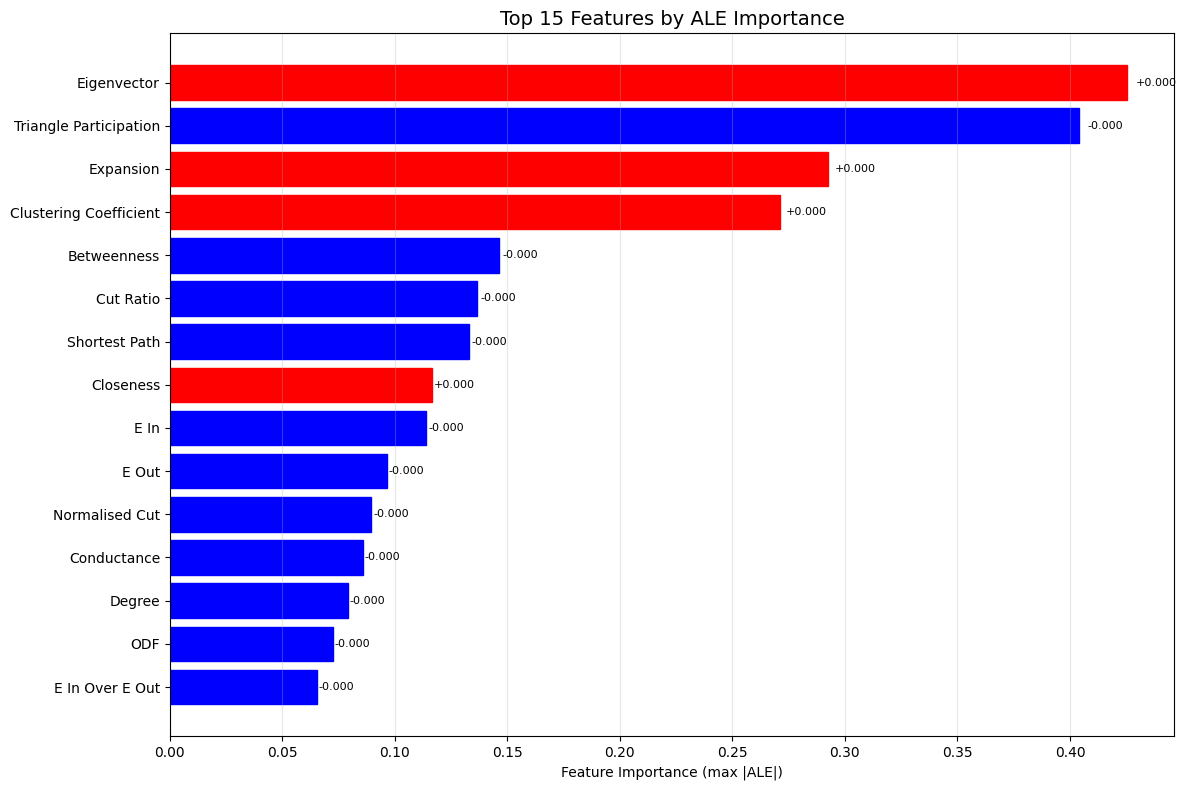


TOP 10 FEATURES BY IMPORTANCE:
                   feature  max_abs_effect   mean_effect  n_graphs
9              Eigenvector        0.425148  3.814940e-05       120
14  Triangle Participation        0.403796 -1.525691e-05       120
10               Expansion        0.292612  4.282952e-05       120
2   Clustering Coefficient        0.270940  5.445338e-05       120
0              Betweenness        0.146189 -2.822812e-05       120
4                Cut Ratio        0.136500 -8.453001e-07       120
13           Shortest Path        0.132874 -1.693585e-04       120
1                Closeness        0.116342  4.976074e-05       120
6                     E In        0.113871 -6.663516e-05       120
8                    E Out        0.096393 -6.924936e-06       120

All results saved to: LFR_Graph_Data/Community_Data/louvain/results/mu_0_4/ale_average_plots


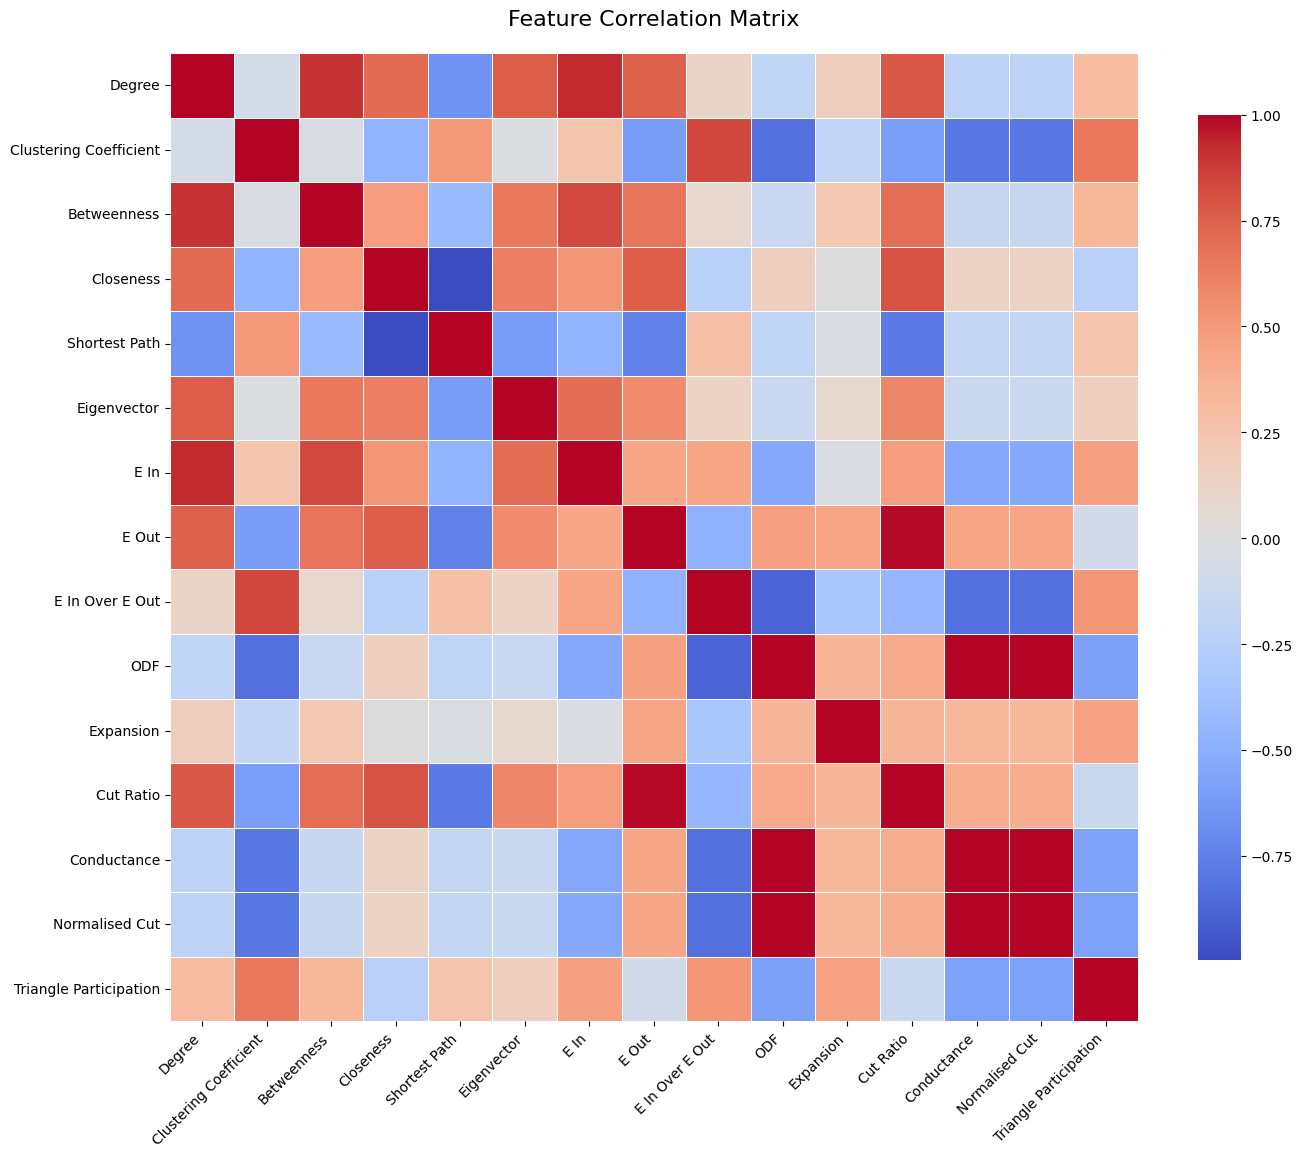

<Figure size 640x480 with 0 Axes>

In [2]:
import os
import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import interpolate

# Load your saved results
results_path = f'LFR_Graph_Data/Community_Data/{algorithm}/results/{mu}/all_graphs_results.pkl'
with open(results_path, 'rb') as f:
    all_results = pickle.load(f)

print(f"Loaded {len(all_results)} graphs")
print("Graph names:", list(all_results.keys()))

# Get all unique features across all graphs
all_features = set()
for graph_name, results in all_results.items():
    if 'ale_curves' in results:
        all_features.update(results['ale_curves'].keys())

print(f"\nFound {len(all_features)} unique features:")
for feature in sorted(all_features):
    print(f"  - {feature}")

# Create output directory
output_dir = f'LFR_Graph_Data/Community_Data/{algorithm}/results/{mu}/ale_average_plots'
os.makedirs(output_dir, exist_ok=True)

# Option 1: Plot each feature individually
def plot_all_features_individual(all_results, output_dir, max_features=None):
    """
    Create individual plots for each feature
    """
    features_list = sorted(all_features)
    
    if max_features is not None:
        features_list = features_list[:max_features]
        print(f"Plotting first {max_features} features...")
    
    for i, feature in enumerate(features_list, 1):
        print(f"\n[{i}/{len(features_list)}] Processing: {feature}")
        
        # Check if feature exists in any graph
        feature_exists = False
        for results in all_results.values():
            if 'ale_curves' in results and feature in results['ale_curves']:
                feature_exists = True
                break
        
        if not feature_exists:
            print(f"  Skipping - not found in any graph")
            continue
        
        # Create figure
        fig, ax = plt.subplots(figsize=(10, 6))
        
        try:
            # Modified version of plot_average_ale_weighted that works without interpolation errors
            plot_average_ale_simple(all_results, feature, ax)
            
            # Save figure
            safe_name = feature.replace('/', '_').replace('\\', '_').replace(':', '_')
            filename = f"ALE_average_{safe_name}.png"
            filepath = os.path.join(output_dir, filename)
            plt.savefig(filepath, dpi=150, bbox_inches='tight')
            print(f"  Saved to {filename}")
            
            # Also save as PDF
            pdf_path = os.path.join(output_dir, f"ALE_average_{safe_name}.pdf")
            plt.savefig(pdf_path, bbox_inches='tight')
            
        except Exception as e:
            print(f"  Error plotting {feature}: {str(e)}")
            plt.close()
            continue
        
        plt.close(fig)

# Option 2: Create grid of plots (multiple features per page)
def plot_features_grid(all_results, output_dir, features_per_page=6):
    """
    Create grid layout with multiple features per page
    """
    features_list = sorted(all_features)
    
    # Calculate number of pages needed
    n_pages = (len(features_list) + features_per_page - 1) // features_per_page
    
    for page in range(n_pages):
        start_idx = page * features_per_page
        end_idx = min(start_idx + features_per_page, len(features_list))
        page_features = features_list[start_idx:end_idx]
        
        # Create subplot grid
        n_cols = 2
        n_rows = (len(page_features) + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
        axes = axes.flatten() if n_rows > 1 else [axes]
        
        for idx, (ax, feature) in enumerate(zip(axes, page_features)):
            print(f"Page {page+1}, Plot {idx+1}: {feature}")
            
            try:
                plot_average_ale_simple(all_results, feature, ax)
                ax.set_title(feature, fontsize=10, pad=5)
            except Exception as e:
                ax.text(0.5, 0.5, f"Error\n{str(e)[:30]}...", 
                       ha='center', va='center', transform=ax.transAxes)
                ax.set_title(f"{feature} (error)", fontsize=10, color='red')
        
        # Hide unused subplots
        for idx in range(len(page_features), len(axes)):
            axes[idx].set_visible(False)
        
        plt.tight_layout()
        
        # Save page
        filename = f"ALE_average_grid_page_{page+1}.png"
        filepath = os.path.join(output_dir, filename)
        plt.savefig(filepath, dpi=150, bbox_inches='tight')
        
        print(f"Saved page {page+1}/{n_pages}")
        plt.close()

# Simplified version of plot_average_ale_weighted that's more robust
def plot_average_ale_simple(all_results, feature, ax=None):
    """
    Simple averaging without interpolation - more robust
    """
    # Collect all curves for this feature
    all_curves = []
    graph_names = []
    
    for graph_name, results in all_results.items():
        if 'ale_curves' in results and feature in results['ale_curves']:
            df = results['ale_curves'][feature]
            all_curves.append(df)
            graph_names.append(graph_name)
    
    if not all_curves:
        raise ValueError(f"Feature '{feature}' not found in any graph")
    
    # Find common x-range
    x_min = min([df['x'].min() for df in all_curves])
    x_max = max([df['x'].max() for df in all_curves])
    
    # Create common grid
    common_x = np.linspace(x_min, x_max, 50)
    
    # Interpolate each curve to common grid
    interpolated_values = []
    
    for df in all_curves:
        # Sort by x
        df_sorted = df.sort_values('x')
        x_vals = df_sorted['x'].values
        y_vals = df_sorted['ale_mean'].values
        
        # Remove duplicates in x
        x_vals, unique_idx = np.unique(x_vals, return_index=True)
        y_vals = y_vals[unique_idx]
        
        # Interpolate
        if len(x_vals) > 1:
            f = interpolate.interp1d(x_vals, y_vals, kind='linear', 
                                    bounds_error=False, fill_value='extrapolate')
            y_interp = f(common_x)
            interpolated_values.append(y_interp)
    
    if not interpolated_values:
        raise ValueError("Could not interpolate any curves")
    
    # Convert to array
    interpolated_values = np.array(interpolated_values)
    
    # Calculate statistics
    mean_curve = np.nanmean(interpolated_values, axis=0)
    std_curve = np.nanstd(interpolated_values, axis=0)
    n_graphs = len(interpolated_values)
    
    # Plot
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot average
    ax.plot(common_x, mean_curve, 'b-', linewidth=2, 
            label=f'Average (n={n_graphs})')
    
    # Plot confidence band
    ax.fill_between(common_x, mean_curve - std_curve, mean_curve + std_curve,
                    alpha=0.2, color='b', label='±1 std')
    
    # Plot a few individual curves
    for i in range(min(3, len(all_curves))):
        df = all_curves[i]
        ax.plot(df['x'], df['ale_mean'], 'gray', alpha=0.3, linewidth=0.5)
    
    # Zero reference line
    ax.axhline(0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
    
    # Labels
    ax.set_xlabel(f'{feature} value', fontsize=11)
    ax.set_ylabel('ALE effect on P(unstable)', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    return ax

# Option 3: Create summary statistics for all features
def create_ale_summary_table(all_results, output_dir):
    """
    Create a CSV with summary statistics for all features
    """
    summary_data = []
    
    for feature in sorted(all_features):
        # Check if feature exists
        has_feature = any('ale_curves' in results and feature in results['ale_curves'] 
                         for results in all_results.values())
        
        if not has_feature:
            continue
        
        # Collect all values
        all_means = []
        for results in all_results.values():
            if 'ale_curves' in results and feature in results['ale_curves']:
                df = results['ale_curves'][feature]
                all_means.extend(df['ale_mean'].values)
        
        if not all_means:
            continue
        
        # Calculate statistics
        all_means = np.array(all_means)
        
        stats = {
            'feature': feature,
            'n_graphs': sum(1 for r in all_results.values() 
                          if 'ale_curves' in r and feature in r['ale_curves']),
            'mean_effect': np.mean(all_means),
            'std_effect': np.std(all_means),
            'max_abs_effect': np.max(np.abs(all_means)),
            'mean_abs_effect': np.mean(np.abs(all_means)),
            'min_effect': np.min(all_means),
            'max_effect': np.max(all_means),
            'q25': np.percentile(all_means, 25),
            'q50': np.percentile(all_means, 50),
            'q75': np.percentile(all_means, 75)
        }
        
        summary_data.append(stats)
    
    # Create DataFrame
    summary_df = pd.DataFrame(summary_data)
    
    # Sort by importance (max absolute effect)
    if not summary_df.empty:
        summary_df = summary_df.sort_values('max_abs_effect', ascending=False)
        
        # Save to CSV
        csv_path = os.path.join(output_dir, 'ale_features_summary.csv')
        summary_df.to_csv(csv_path, index=False)
        print(f"\nSummary saved to: {csv_path}")
        
        # Create feature importance plot
        fig, ax = plt.subplots(figsize=(12, 8))
        top_n = min(20, len(summary_df))
        
        y_pos = np.arange(top_n)
        bars = ax.barh(y_pos, summary_df['max_abs_effect'].head(top_n))
        
        # Color bars by sign of mean effect
        for i, bar in enumerate(bars):
            mean_effect = summary_df.iloc[i]['mean_effect']
            bar.set_color('red' if mean_effect > 0 else 'blue')
        
        ax.set_yticks(y_pos)
        ax.set_yticklabels(summary_df['feature'].head(top_n))
        ax.invert_yaxis()
        ax.set_xlabel('Feature Importance (max |ALE|)')
        ax.set_title(f'Top {top_n} Features by ALE Importance', fontsize=14)
        ax.grid(True, alpha=0.3, axis='x')
        
        # Add mean effect as text
        for i, (idx, row) in enumerate(summary_df.head(top_n).iterrows()):
            sign = '+' if row['mean_effect'] > 0 else ''
            ax.text(row['max_abs_effect'] * 1.01, i, 
                   f"{sign}{row['mean_effect']:.3f}", 
                   va='center', fontsize=8)
        
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, 'feature_importance_ranking.png'), 
                   dpi=150, bbox_inches='tight')
        plt.show()
    
    return summary_df

print("=" * 60)
print("ALE AVERAGE ANALYSIS FOR ALL FEATURES")
print("=" * 60)

# Method 1: Individual plots
print("\n1. Creating individual plots...")
plot_all_features_individual(all_results, output_dir, max_features=None)

# Method 2: Grid plots
print("\n2. Creating grid plots...")
plot_features_grid(all_results, output_dir, features_per_page=8)

# Method 3: Summary table
print("\n3. Creating summary statistics...")
summary_df = create_ale_summary_table(all_results, output_dir)
    
# Display top features
if summary_df is not None and not summary_df.empty:
    print("\n" + "=" * 60)
    print("TOP 10 FEATURES BY IMPORTANCE:")
    print("=" * 60)
    print(summary_df[['feature', 'max_abs_effect', 'mean_effect', 'n_graphs']].head(10).to_string())
    
    # Also print to file
    with open(os.path.join(output_dir, 'top_features.txt'), 'w') as f:
        f.write("TOP 10 FEATURES BY ALE IMPORTANCE\n")
        f.write("=" * 40 + "\n\n")
        f.write(summary_df[['feature', 'max_abs_effect', 'mean_effect', 'n_graphs']].head(10).to_string())

print(f"\n" + "=" * 60)
print(f"All results saved to: {output_dir}")
print("=" * 60)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Load all feature CSVs
feats_folder = f'LFR_Graph_Data/Community_Data/{algorithm}/Node_Features/'
all_dfs = []

for csv_file in os.listdir(feats_folder):
    if csv_file.endswith('_features.csv'):
        df = pd.read_csv(os.path.join(feats_folder, csv_file))
        all_dfs.append(df)

# Combine
features_df = pd.concat(all_dfs, ignore_index=True)

# Calculate correlation
corr_matrix = features_df.select_dtypes(include=[np.number]).corr()

# Plot
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, square=True, 
           linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Save
output_dir = 'correlation_results'
os.makedirs(output_dir, exist_ok=True)
corr_matrix.to_csv(os.path.join(output_dir, 'correlation_matrix.csv'))
plt.savefig(os.path.join(output_dir, 'correlation_heatmap.png'), dpi=300, bbox_inches='tight')